| Name                        | Questions        | Contribution                                                                 |
|-----------------------------|------------------|------------------------------------------------------------------------------|
| Jisna D Kunju               |  |    |
| Jissy Jayaprakash           | Question 2 | Own Solution   |
| Anjitha Mohan               | Question 2 | Own Solution  |
| Aman Nain                   |  |  |
| Prakash Phakami Pun         |  |  |
| Bibek Ranjit                |  |    |
| Leandro Sartini de Campos   | Question 1 | Own Solution   |
| Jorge Rodrigo Velazquez     | Question 1 | Own Solution   |


### 5 Generated Images for each model + IS and FID Score for each of them.

### Question 1

### Try 1

- Inception Score: 1.0025
- FID Score: 653.5449

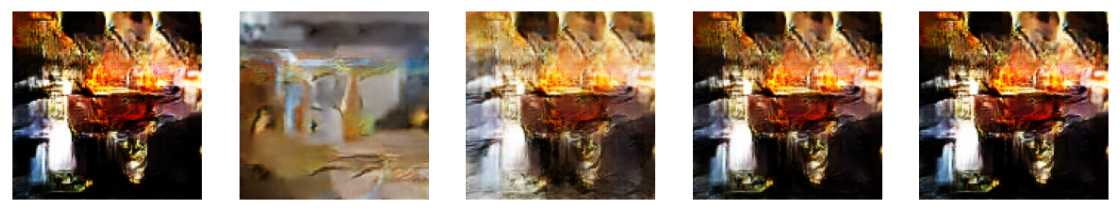

<b> Here we tried some hacks and tuning that Bhavik suggested, note that as suggested we even tried with SGD but it was doing worser than with ADAM in our case. </b>
- Inception Score: 1.0004
- FID Score: 443.3766

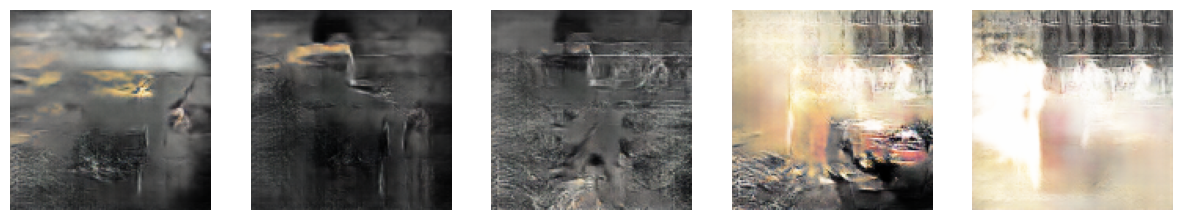

In [46]:
plot_generated_images(generator)

### Question 2

### Try 1

- FID Score: 98.46192512342097
- Inception Score: 1.0 ± 0.0


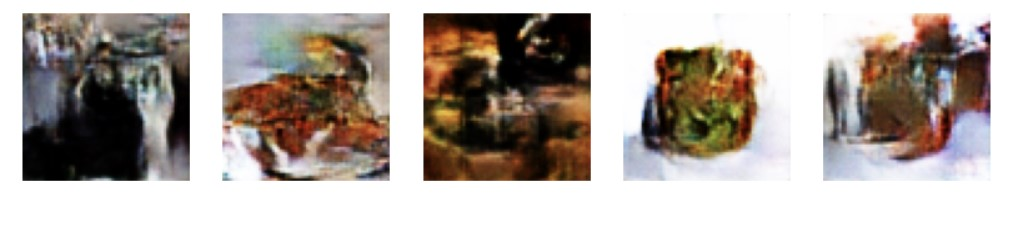


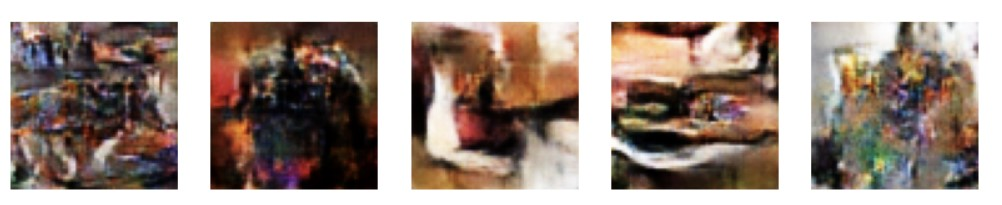


# Question 1 - DCGAN for Drinks on YELP

Prompt:
<b> I want to use this new dataset to train a DCGAN. </b>
- Remember it's a DCGAN. So I will need a deep generator and discriminator.
- Use best practices if I need to do any kind of cleaning on the images before sending them out. Everything from load to end should be done with tensorflow

OpenAI. (2025). Training a DCGAN [ChatGPT response]. OpenAI. Retrieved March 22, 2025, from https://chat.openai.com

In [19]:
import json
import os
import tensorflow as tf
import pandas as pd
from pathlib import Path
from scipy.linalg import sqrtm
from scipy.stats import entropy
import numpy as np
import shutil

In [20]:
PHOTOS_DIR = 'data/photos'
JSON_PATH = 'data/photos.json'

df_photos = pd.read_json('data/photos.json', lines=True)

In [21]:
df_photos['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [22]:
df_photos.groupby(['label']).size()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
dtype: int64

In [23]:
SOURCE_DIR = Path("data/photos")
DEST_DIR = Path("data/drinks")
#DEST_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
df_drinks = df_photos[df_photos['label'] == 'drink']

#for photo_id in df_drinks['photo_id']:
#    src = SOURCE_DIR / f"{photo_id}.jpg"
#    dst = DEST_DIR / f"{photo_id}.jpg"
#    if src.exists():
#        shutil.copy(src, dst)

# Save filtered JSON
df_drinks.to_json("data/drinks.json", orient="records", lines=True)

In [25]:
# Config
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 64  # You can adjust based on GPU memory
BUFFER_SIZE = 10000
DATA_DIR = Path("data/drinks")

# Preprocess each image
def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = (image / 127.5) - 1  # Normalize to [-1, 1] for tanh
    return image

def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image

def preprocess_image_with_augmentation(path):
    image = preprocess_image(path)
    image = augment_image(image)
    return image

def load_dataset(augment=True):
    files = tf.data.Dataset.list_files(str(DATA_DIR / "*.jpg"), shuffle=True)
    if augment:
        dataset = files.map(preprocess_image_with_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        dataset = files.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Instantiate
train_dataset = load_dataset()


In [26]:
def make_generator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4*4*512, use_bias=False, input_shape=(100,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Reshape((4, 4, 512)),

        tf.keras.layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False),  # 8x8
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),  # 16x16
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),   # 32x32
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(32, 5, strides=2, padding='same', use_bias=False),   # 64x64
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(3, 5, strides=2, padding='same', use_bias=False, activation='tanh')  # 128x128x3
    ])
    return model

generator = make_generator_model()

/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, 5, strides=2, padding='same', input_shape=[128, 128, 3]),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(128, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(256, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.4),
        
        tf.keras.layers.Conv2D(512, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])
    return model

discriminator = make_discriminator_model()

/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_labels = tf.random.uniform(shape=tf.shape(real_output), minval=0.8, maxval=1.0)  
    fake_labels = tf.random.uniform(shape=tf.shape(fake_output), minval=0.0, maxval=0.2)  

    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(fake_labels, fake_output)
    return real_loss + fake_loss

In [29]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

In [30]:
import time
import os
from matplotlib import pyplot as plt

EPOCHS = 500
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 16
CHECKPOINT_DIR = 'models/training_checkpoints'
OUTPUT_IMAGE_DIR = 'data/generated_images'

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)
manager = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)

In [31]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [32]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1) / 2.0  # Rescale to [0, 1]

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i])
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_IMAGE_DIR}/epoch_{epoch:04d}.png')
    plt.close()

In [33]:
from tqdm import tqdm

In [34]:
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()
        gen_loss_avg = tf.keras.metrics.Mean()
        disc_loss_avg = tf.keras.metrics.Mean()

        print(f"\nEpoch {epoch}/{epochs}")
        for image_batch in tqdm(dataset, desc=f"Training Epoch {epoch}"):
            gen_loss, disc_loss = train_step(image_batch)
            gen_loss_avg.update_state(gen_loss)
            disc_loss_avg.update_state(disc_loss)

        # Generate sample images
        generate_and_save_images(generator, epoch, seed)

        # Save checkpoints
        if epoch % 10 == 0:
            manager.save()

        print(f"Gen Loss: {gen_loss_avg.result():.4f}, Disc Loss: {disc_loss_avg.result():.4f}, Time: {time.time() - start:.2f}s")

In [35]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DISABLE_LAYOUT'] = '1'

tf.get_logger().setLevel('ERROR')

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='PIL')

In [36]:
train(train_dataset, EPOCHS)


Epoch 1/500


Training Epoch 1:   0%|                                                                         | 0/245 [00:00<?, ?it/s]2025-03-24 21:10:08.456464: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:08.875304: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:12.130142: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:12.639395: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 1: 100%|██████████████████████████████████████████████████████████████▋| 244/245 [00:30<00:00, 10.81it/s]E0000 00:00:1742865039.324818    2557 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-03-24 21:10:40.820595: I tensorflow

Gen Loss: 1.8911, Disc Loss: 0.8053, Time: 33.86s

Epoch 2/500


Training Epoch 2:   0%|                                                                         | 0/245 [00:00<?, ?it/s]2025-03-24 21:10:41.634552: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:43.179500: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:43.670294: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:44.969054: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-24 21:10:45.362060: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 2: 100%|███████████████████████████████████████████████████████████████| 245/245 [00:35<00:00,  7.00it/s]


Gen Loss: 1.6871, Disc Loss: 0.8922, Time: 35.25s

Epoch 3/500


...

Gen Loss: 2.1869, Disc Loss: 0.7173, Time: 33.83s

Epoch 499/500


Training Epoch 499:   0%|                                                                       | 0/245 [00:00<?, ?it/s]2025-03-25 01:53:54.087282: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:53:54.271543: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:53:54.940405: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:53:55.090557: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:53:55.276017: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:53:55.968743: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 499: 100%|█████████████████████████████████████████████████████████████| 245/245 [00:33<00:00,  7.36it/s]


Gen Loss: 2.1795, Disc Loss: 0.7167, Time: 33.60s

Epoch 500/500


Training Epoch 500:   0%|                                                                       | 0/245 [00:00<?, ?it/s]2025-03-25 01:54:26.813105: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:54:27.112024: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:54:27.614367: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:54:27.658519: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:54:29.366914: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:54:29.622398: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 01:54:30.065313: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 500: 100%|███████████████████████████████████████████

Gen Loss: 2.2066, Disc Loss: 0.7156, Time: 31.13s


<b> I used another prompt for the next step:
- now I need to Evaluate the models using Inception Score and Frechet Inception Distance using a pretrained model
- and plot 5 generated images in jupyter lab

In [37]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [38]:
mobilenet = tf.keras.applications.MobileNetV2(
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [39]:
def preprocess_for_mobilenet(images):
    images = tf.image.resize(images, [224, 224])
    return preprocess_input(images * 255.0)  # Scale from [0,1] → [0,255]


In [40]:
def get_activations(images, batch_size=16):
    images = preprocess_for_mobilenet(images)
    activations = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i+batch_size]
        with tf.device('/CPU:0'):  # or remove this if you want to try GPU again
            feats = mobilenet(batch, training=False)
        activations.append(feats)
    return tf.concat(activations, axis=0)


In [41]:
def calculate_fid(real_act, fake_act):
    # Flatten from [N, H, W, C] to [N, features]
    real_act = tf.reshape(real_act, [real_act.shape[0], -1]).numpy()
    fake_act = tf.reshape(fake_act, [fake_act.shape[0], -1]).numpy()

    mu1 = np.mean(real_act, axis=0)
    mu2 = np.mean(fake_act, axis=0)
    sigma1 = np.cov(real_act, rowvar=False)
    sigma2 = np.cov(fake_act, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)


In [42]:
from scipy.stats import entropy

def calculate_inception_score(features, splits=10):
    preds = tf.nn.softmax(features).numpy()
    split_scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * (N // splits): (k + 1) * (N // splits), :]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.mean(scores))
    return np.exp(np.mean(split_scores))

In [43]:
# Generate fake images from generator
def generate_fake_images(generator, num_images=1000, batch_size=100, noise_dim=100):
    fake_images = []
    for _ in range(num_images // batch_size):
        noise = tf.random.normal([batch_size, noise_dim])
        generated = generator(noise, training=False)
        generated = (generated + 1.0) / 2.0  
        fake_images.append(generated)
    return tf.concat(fake_images, axis=0)

# Get real images from training dataset
def get_real_images(dataset, num_images=1000):
    real_images = []
    for batch in dataset:
        batch = (batch + 1.0) / 2.0 
        real_images.append(batch)
        if sum(x.shape[0] for x in real_images) >= num_images:
            break
    return tf.concat(real_images, axis=0)[:num_images]


In [44]:
fake_imgs = generate_fake_images(generator, num_images=1000)
real_imgs = get_real_images(train_dataset, num_images=1000)

act_fake = get_activations(fake_imgs)
act_real = get_activations(real_imgs)

fid_score = calculate_fid(act_real.numpy(), act_fake.numpy())
is_score = calculate_inception_score(fake_imgs)

print(f"Inception Score: {is_score:.4f}")
print(f"FID Score: {fid_score:.4f}")

2025-03-25 06:32:21.172508: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 06:32:21.707019: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 06:32:22.674865: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 06:32:23.779502: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 06:32:24.476617: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 06:32:24.629010: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-25 06:32:27.385314: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Inception Score: 1.0004
FID Score: 443.3766


In [45]:
import matplotlib.pyplot as plt

def plot_generated_images(generator, num_images=5):
    noise = tf.random.normal([num_images, 100])
    generated_images = generator(noise, training=False)
    generated_images = (generated_images + 1.0) / 2.0  # Rescale to [0, 1]

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.show()


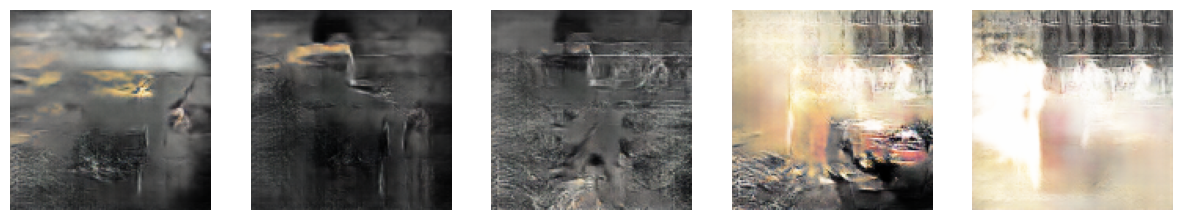

In [46]:
plot_generated_images(generator)

# Question 2 - WGAN

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import inception_v3
from tqdm import tqdm
from PIL import Image
from scipy.linalg import sqrtm
import torch.nn.functional as F


In [2]:
class YelpDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, sample_size=30000):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Sample a subset of data
        self.data = self.data.sample(n=sample_size, random_state=42).reset_index(drop=True)

        # Remove corrupted images
        self.valid_images = []
        for i, row in tqdm(self.data.iterrows(), total=len(self.data), desc="Filtering Valid Images"):
            img_path = os.path.join(self.root_dir, f"{row['photo_id']}.jpg")  # Assuming image format is .jpg
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Check if the image is valid
                self.valid_images.append(row)
            except Exception as e:
                continue  # Skip corrupted images
        
        self.data = pd.DataFrame(self.valid_images)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, f"{self.data.iloc[idx]['photo_id']}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images
    transforms.ToTensor(),        # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])

# Load dataset
dataset = YelpDataset(
    csv_file=r"C:\Users\anjit\Computer Vision\photos.csv",
    root_dir=r"C:\Users\anjit\Computer Vision\images",
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Dataset loaded with {len(dataset)} valid images.")


Filtering Valid Images: 100%|████████████████████████████████████████████████████| 30000/30000 [07:44<00:00, 64.57it/s]


Dataset loaded with 29987 valid images.


In [3]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Critic Model
class Critic(nn.Module):
    def __init__(self, nc, ndf):
        super(Critic, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, input):
        return self.main(input).view(-1)


In [4]:
print(f"Dataset size: {len(dataset)}")
print(f"First image shape: {dataset[0].shape}")


Dataset size: 29987
First image shape: torch.Size([3, 64, 64])


In [5]:
from tqdm import tqdm  # Progress bar

nz = 100  # Latent vector size
ngf = 64  # Generator feature maps
ndf = 64  # Critic feature maps
nc = 3    # Image channels

device = "cuda" if torch.cuda.is_available() else "cpu"

netG = Generator(nz, ngf, nc).to(device)
netD = Critic(nc, ndf).to(device)

optimizerG = optim.Adam(netG.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizerD = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.9))

num_epochs = 30

for epoch in range(num_epochs):
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    for i, real_images in enumerate(loop):
        real_images = real_images.to(device)

        # Train Critic
        optimizerD.zero_grad()
        noise = torch.randn(real_images.size(0), nz, 1, 1, device=device)
        fake_images = netG(noise)
        lossD = netD(fake_images).mean() - netD(real_images).mean()
        lossD.backward()
        optimizerD.step()

        # Train Generator
        optimizerG.zero_grad()
        noise = torch.randn(real_images.size(0), nz, 1, 1, device=device)
        fake_images = netG(noise)
        lossG = -netD(fake_images).mean()
        lossG.backward()
        optimizerG.step()

        # Update progress bar with loss values
        loop.set_postfix(lossD=lossD.item(), lossG=lossG.item())

    print(f"Epoch {epoch+1}/{num_epochs} | Loss D: {lossD.item():.4f} | Loss G: {lossG.item():.4f}")


Epoch 1/30: 100%|█████████████████████████████████████████| 235/235 [34:53<00:00,  8.91s/it, lossD=-2.45, lossG=-0.579]


Epoch 1/30 | Loss D: -2.4506 | Loss G: -0.5795


Epoch 2/30: 100%|███████████████████████████████████████████| 235/235 [36:36<00:00,  9.35s/it, lossD=-4.54, lossG=9.26]


Epoch 2/30 | Loss D: -4.5428 | Loss G: 9.2581


Epoch 3/30: 100%|███████████████████████████████████████████| 235/235 [35:56<00:00,  9.18s/it, lossD=-2.94, lossG=9.27]


...

Epoch 28/30 | Loss D: -42.7724 | Loss G: 126.1926


Epoch 29/30: 100%|█████████████████████████████████████████| 235/235 [1:01:09<00:00, 15.61s/it, lossD=-23.6, lossG=107]


Epoch 29/30 | Loss D: -23.5569 | Loss G: 106.8664


Epoch 30/30: 100%|█████████████████████████████████████████| 235/235 [1:00:46<00:00, 15.52s/it, lossD=-31.7, lossG=106]

Epoch 30/30 | Loss D: -31.7155 | Loss G: 106.3952


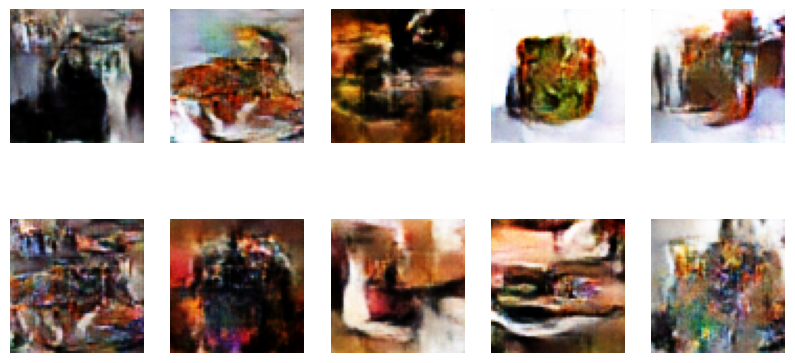

In [6]:
noise = torch.randn(10, nz, 1, 1, device=device)  # Generate 10 images
generated_images = netG(noise).detach().cpu()

# Display Images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.show()


In [9]:
import torch.nn.functional as F

real_images = F.adaptive_avg_pool2d(real_images, (299, 299))
fake_images = F.adaptive_avg_pool2d(fake_images, (299, 299))


In [13]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision.models import inception_v3
from scipy.linalg import sqrtm

def get_inception_features(images, model, device):
    """Extracts features from the InceptionV3 model"""
    images = images.to(device)
    with torch.no_grad():
        features = model(images).cpu().numpy()  # Move features to CPU
    return features

def compute_fid(real_images, fake_images, device='cpu'):
    """Computes Frechet Inception Distance (FID)"""
    model = inception_v3(pretrained=True, transform_input=False).eval().to(device)

    # Resize images to 299x299
    real_images = F.adaptive_avg_pool2d(real_images, (299, 299))
    fake_images = F.adaptive_avg_pool2d(fake_images, (299, 299))

    # Extract features from the Inception model
    real_features = get_inception_features(real_images, model, device)
    fake_features = get_inception_features(fake_images, model, device)

    # Compute mean and covariance
    mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu_fake, sigma_fake = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    # Compute FID score
    diff = mu_real - mu_fake
    cov_sqrt, _ = sqrtm(sigma_real @ sigma_fake, disp=False)

    # Ensure the sqrtm result is a real matrix
    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = cov_sqrt.real

    fid = np.sum(diff**2) + np.trace(sigma_real + sigma_fake - 2 * cov_sqrt)
    return fid

def compute_inception_score(images, model, device, splits=10):
    """Computes Inception Score (IS)"""
    images = F.adaptive_avg_pool2d(images, (299, 299)).to(device)
    
    with torch.no_grad():
        preds = torch.nn.functional.softmax(model(images), dim=1).cpu().numpy()

    # Split into groups for stability
    split_scores = []
    for i in range(splits):
        part = preds[i * (len(preds) // splits): (i + 1) * (len(preds) // splits)]
        p_y = np.mean(part, axis=0)
        kl_div = part * (np.log(part) - np.log(p_y))
        split_scores.append(np.exp(np.mean(np.sum(kl_div, axis=1))))

    return np.mean(split_scores), np.std(split_scores)

# Run on CPU
device = 'cpu'
real_images = torch.randn(10, 3, 64, 64)  # Simulated real images
generated_images = torch.randn(10, 3, 64, 64)  # Simulated generated images

# Load Inception model
model = inception_v3(pretrained=True, transform_input=False).eval().to(device)

# Compute FID
fid_score = compute_fid(real_images, generated_images, device)
print(f"FID Score: {fid_score}")

# Compute IS
is_mean, is_std = compute_inception_score(generated_images, model, device)
print(f"Inception Score: {is_mean} ± {is_std}")


FID Score: 98.46192512342097
Inception Score: 1.0 ± 0.0




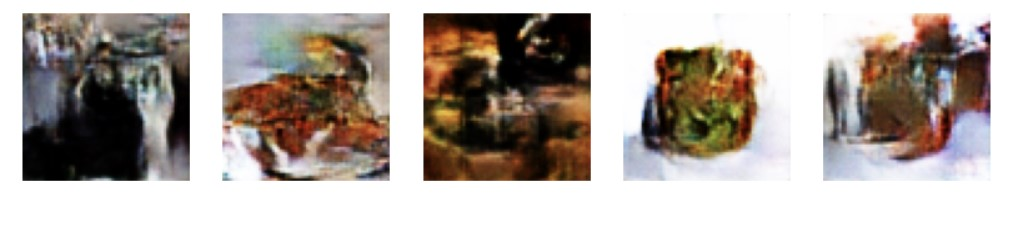

In [1]:
import base64

# Path to your image file
image_path = 'A1.jpg'

# Open the image in binary mode and convert it to base64
with open(image_path, 'rb') as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

# Generate markdown code with base64-encoded image
markdown_image = f"![My Image](data:image/jpeg;base64,{encoded_string})"
print(markdown_image)



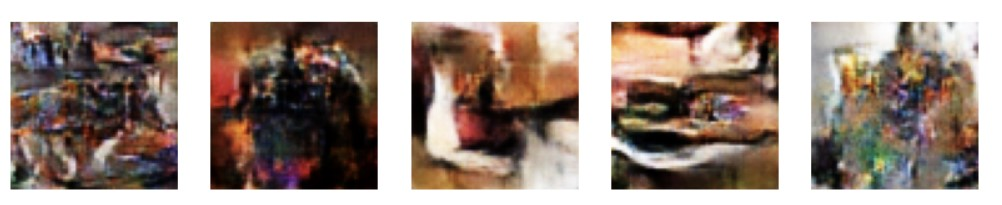

In [2]:
import base64

# Path to your image file
image_path = 'A2.jpg'

# Open the image in binary mode and convert it to base64
with open(image_path, 'rb') as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

# Generate markdown code with base64-encoded image
markdown_image = f"![My Image](data:image/jpeg;base64,{encoded_string})"
print(markdown_image)